## 1. Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Load Dataset

In [51]:
df = pd.read_csv('fordgobike-tripdataFor201902.csv')
df_raw = df.copy()

print("Shape:", df.shape)
df.head()


Shape: (183416, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


## 3. Initial Data Inspection

In [52]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 183416
Number of columns: 16


In [53]:
print(list(df.columns))


['duration_sec', 'start_time', 'end_time', 'start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type', 'member_birth_year', 'member_gender', 'bike_share_for_all_trip']


In [54]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [55]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct(%)
member_birth_year,8265,4.51
member_gender,8265,4.51
start_station_name,197,0.11
start_station_id,197,0.11
end_station_name,197,0.11
end_station_id,197,0.11


### Duplicate Records

In [56]:
dup_count = df.duplicated().sum()
print("Number of fully duplicated rows:", dup_count)

df[df.duplicated(keep=False)].sort_values(list(df.columns))

Number of fully duplicated rows: 4


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
183410,139,05:34.4,07:54.3,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,-122.275698,5095,Subscriber,1988.0,Male,No
183414,139,05:34.4,07:54.3,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,-122.275698,5095,Subscriber,1988.0,Male,No
183409,141,06:05.5,08:27.2,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,-121.908586,3824,Subscriber,1990.0,Male,Yes
183413,141,06:05.5,08:27.2,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,-121.908586,3824,Subscriber,1990.0,Male,Yes
183411,271,00:20.6,04:52.1,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,-122.395936,1057,Subscriber,1989.0,Male,No
183415,271,00:20.6,04:52.1,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,-122.395936,1057,Subscriber,1989.0,Male,No
183408,313,05:34.7,10:48.5,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,-122.392741,4960,Subscriber,1984.0,Male,No
183412,313,05:34.7,10:48.5,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,-122.392741,4960,Subscriber,1984.0,Male,No


### Statistical Summary

In [57]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [58]:
df.describe(include=['object'])

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,start_time,end_time,start_station_name,end_station_name,user_type,member_gender,bike_share_for_all_trip
count,183416,183416,183219,183219,183416,175151,183416
unique,35783,35767,329,329,2,3,2
top,12:19.2,22:24.4,Market St at 10th St,San Francisco Caltrain Station 2 (Townsend St...,Subscriber,Male,No
freq,16,20,3904,4857,163548,130655,166056


## 4. Data Cleaning

### Remove Duplicate Records

In [59]:
print("Shape before removing duplicates:", df.shape)
n_dupes = df.duplicated().sum()
pct_dupes = n_dupes / len(df) * 100
print(f"Duplicate rows to remove: {n_dupes} ({pct_dupes:.4f}% of the dataset)")

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (183416, 16)
Duplicate rows to remove: 4 (0.0022% of the dataset)
Shape after removing duplicates: (183412, 16)
Remaining duplicate rows: 0


### Date & Time Conversion

In [60]:
df[['start_time', 'end_time']].head(10)


,start_time,end_time
0,32:10.1,01:56.0
1,53:21.8,42:03.1
2,13:13.2,24:08.1
3,54:26.0,02:36.8
4,54:18.5,20:44.1
5,49:58.6,19:51.8
6,55:35.1,14:42.6
7,41:06.8,08:02.8
8,41:48.8,07:59.7
9,49:47.7,07:17.0


In [61]:
print("Unique string lengths in start_time:")
print(df['start_time'].astype(str).str.len().value_counts())
print()
print("Unique string lengths in end_time:")
print(df['end_time'].astype(str).str.len().value_counts())
print()
print("Sample of raw start_time values:")
print(df['start_time'].head(15).tolist())


Unique string lengths in start_time:
start_time
7    183412
Name: count, dtype: int64

Unique string lengths in end_time:
end_time
7    183412
Name: count, dtype: int64

Sample of raw start_time values:
['32:10.1', '53:21.8', '13:13.2', '54:26.0', '54:18.5', '49:58.6', '55:35.1', '41:06.8', '41:48.8', '49:47.7', '57:57.2', '56:55.5', '45:12.7', '49:06.1', '56:26.8']


In [62]:
parsed_test = pd.to_datetime(df['start_time'], errors='coerce')
print("Rows that failed to parse (NaT):", parsed_test.isna().sum(), "out of", len(df))
print()
print("Rows that DID parse — inspect what pandas guessed for them:")
parsed_ok_idx = parsed_test.notna()
print(pd.DataFrame({'original': df.loc[parsed_ok_idx, 'start_time'].head(5),
                     'parsed_by_pandas': parsed_test[parsed_ok_idx].head(5)}))

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\1678801831.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_test = pd.to_datetime(df['start_time'], errors='coerce')


Rows that failed to parse (NaT): 109501 out of 183412

Rows that DID parse — inspect what pandas guessed for them:
   original    parsed_by_pandas
2   13:13.2 2026-09-12 13:13:12
42  20:24.1 2026-09-12 20:24:06
50  15:30.5 2026-09-12 15:30:30
61  18:17.9 2026-09-12 18:17:54
64  18:53.1 2026-09-12 18:53:06


### Missing Values Treatment

In [63]:
for col in ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name',
            'member_birth_year', 'member_gender']:
    n_missing = df[col].isna().sum()
    pct_missing = n_missing / len(df) * 100
    print(f"{col:22s} | missing={n_missing:6d} | pct={pct_missing:5.2f}% | dtype={df[col].dtype}")


start_station_id       | missing=   197 | pct= 0.11% | dtype=float64
start_station_name     | missing=   197 | pct= 0.11% | dtype=str
end_station_id         | missing=   197 | pct= 0.11% | dtype=float64
end_station_name       | missing=   197 | pct= 0.11% | dtype=str
member_birth_year      | missing=  8265 | pct= 4.51% | dtype=float64
member_gender          | missing=  8265 | pct= 4.51% | dtype=str


In [64]:
start_null = df['start_station_id'].isna()
end_null = df['end_station_id'].isna()
print("Rows missing start_station_id:", start_null.sum())
print("Rows missing end_station_id:", end_null.sum())
print("Rows missing BOTH:", (start_null & end_null).sum())

print()
print("Do these rows still have valid coordinates?")
print(df.loc[start_null, ['start_station_latitude', 'start_station_longitude',
                            'end_station_latitude', 'end_station_longitude']].isna().sum())

Rows missing start_station_id: 197
Rows missing end_station_id: 197
Rows missing BOTH: 197

Do these rows still have valid coordinates?
start_station_latitude     0
start_station_longitude    0
end_station_latitude       0
end_station_longitude      0
dtype: int64


In [65]:
by_null = df['member_birth_year'].isna()
g_null = df['member_gender'].isna()
print("Missing member_birth_year:", by_null.sum())
print("Missing member_gender:", g_null.sum())
print("Missing BOTH on the same rows:", (by_null & g_null).sum())
print("Missing only one of the two:", ((by_null ^ g_null)).sum())

print()
print("Breakdown by user_type for rows missing demographic info:")
print(df.loc[by_null, 'user_type'].value_counts())

Missing member_birth_year: 8265
Missing member_gender: 8265
Missing BOTH on the same rows: 8265
Missing only one of the two: 0

Breakdown by user_type for rows missing demographic info:
user_type
Subscriber    5028
Customer      3237
Name: count, dtype: int64


### Invalid Values

In [66]:
print("Youngest 5 birth years (oldest riders):")
print(df['member_birth_year'].value_counts().sort_index().head(15))


Youngest 5 birth years (oldest riders):
member_birth_year
1878.0     1
1900.0    53
1901.0     6
1902.0    11
1910.0     1
1920.0     3
1927.0     1
1928.0     1
1930.0     1
1931.0    89
1933.0    20
1934.0     2
1938.0     3
1939.0    11
1941.0     9
Name: count, dtype: int64


In [67]:
for y in range(1895, 1905):
    print(y, (df['member_birth_year'] == y).sum())

1895 0
1896 0
1897 0
1898 0
1899 0
1900 53
1901 6
1902 11
1903 0
1904 0


In [68]:
REFERENCE_YEAR = 2019  

implausible_age_mask = (REFERENCE_YEAR - df['member_birth_year']) >= 100
n_affected = implausible_age_mask.sum()
print(f"Rows with implied age >= 100: {n_affected} ({n_affected/len(df)*100:.4f}% of the dataset)")
print()
print(df.loc[implausible_age_mask, 'member_birth_year'].value_counts().sort_index())


Rows with implied age >= 100: 72 (0.0393% of the dataset)

member_birth_year
1878.0     1
1900.0    53
1901.0     6
1902.0    11
1910.0     1
Name: count, dtype: int64


In [69]:
print("Rows before treatment:", len(df))

df.loc[implausible_age_mask, 'member_birth_year'] = np.nan

print("Rows after treatment (unchanged — no rows deleted):", len(df))
print("member_birth_year missing values after treatment:", df['member_birth_year'].isna().sum())

Rows before treatment: 183412
Rows after treatment (unchanged — no rows deleted): 183412
member_birth_year missing values after treatment: 8337


In [70]:
print("Negative or zero duration_sec:", (df['duration_sec'] <= 0).sum())
print("Minimum duration_sec:", df['duration_sec'].min(), "seconds")
print("Maximum duration_sec:", df['duration_sec'].max(), "seconds", "=", round(df['duration_sec'].max()/3600, 2), "hours")
print()
print("Latitude range (start):", df['start_station_latitude'].min(), "to", df['start_station_latitude'].max())
print("Longitude range (start):", df['start_station_longitude'].min(), "to", df['start_station_longitude'].max())
print("Latitude range (end):", df['end_station_latitude'].min(), "to", df['end_station_latitude'].max())
print("Longitude range (end):", df['end_station_longitude'].min(), "to", df['end_station_longitude'].max())


Negative or zero duration_sec: 0
Minimum duration_sec: 61 seconds
Maximum duration_sec: 85444 seconds = 23.73 hours

Latitude range (start): 37.3172979 to 37.88022245
Longitude range (start): -122.4537045 to -121.8741186
Latitude range (end): 37.3172979 to 37.88022245
Longitude range (end): -122.4537045 to -121.8741186


### Outlier Detection and Treatment

In [71]:
Q1 = df['duration_sec'].quantile(0.25)
Q3 = df['duration_sec'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = (df['duration_sec'] > upper_bound).sum()
pct_outliers = n_outliers / len(df) * 100

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"IQR upper bound: {upper_bound:.1f} seconds (~{upper_bound/60:.1f} minutes)")
print(f"Rows above upper bound: {n_outliers} ({pct_outliers:.2f}% of the dataset)")
print(f"Rows below lower bound ({lower_bound:.1f}): {(df['duration_sec'] < lower_bound).sum()} (not possible since duration_sec has no negative values)")


Q1=325.0, Q3=796.0, IQR=471.0
IQR upper bound: 1502.5 seconds (~25.0 minutes)
Rows above upper bound: 10131 (5.52% of the dataset)
Rows below lower bound (-381.5): 0 (not possible since duration_sec has no negative values)


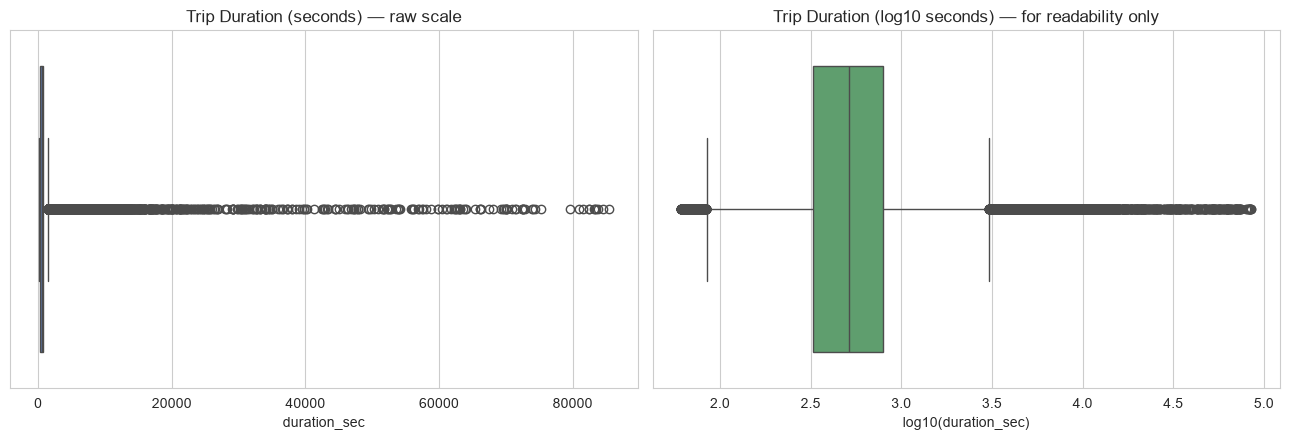

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x=df['duration_sec'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Trip Duration (seconds) — raw scale')
axes[0].set_xlabel('duration_sec')

sns.boxplot(x=np.log10(df['duration_sec']), ax=axes[1], color='#55A868')
axes[1].set_title('Trip Duration (log10 seconds) — for readability only')
axes[1].set_xlabel('log10(duration_sec)')

plt.tight_layout()
plt.show()

In [73]:
for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- user_type ---
user_type
Subscriber    163544
Customer       19868
Name: count, dtype: int64

--- member_gender ---
member_gender
Male      130651
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64

--- bike_share_for_all_trip ---
bike_share_for_all_trip
No     166053
Yes     17359
Name: count, dtype: int64



## 5. Feature Engineering

### Trip Duration in Minutes

In [74]:
df['trip_duration_minutes'] = df['duration_sec'] / 60

print(df[['duration_sec', 'trip_duration_minutes']].head())
print()
print(df['trip_duration_minutes'].describe())

   duration_sec  trip_duration_minutes
0         52185             869.750000
1         42521             708.683333
2         61854            1030.900000
3         36490             608.166667
4          1585              26.416667

count    183412.000000
mean         12.101307
std          29.906496
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: trip_duration_minutes, dtype: float64


### Age

In [75]:
print("Reference year used:", REFERENCE_YEAR)

df['age'] = REFERENCE_YEAR - df['member_birth_year']

print(df[['member_birth_year', 'age']].describe())


Reference year used: 2019
       member_birth_year            age
count      175075.000000  175075.000000
mean         1984.841222      34.158778
std             9.972079       9.972079
min          1920.000000      18.000000
25%          1980.000000      27.000000
50%          1987.000000      32.000000
75%          1992.000000      39.000000
max          2001.000000      99.000000


In [76]:
def age_group(age):
    if pd.isna(age):
        return np.nan
    elif age <= 24:
        return 'Young'
    elif age <= 59:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)

print(df['age_group'].value_counts(dropna=False))

age_group
Adult     148001
Young      22992
NaN         8337
Senior      4082
Name: count, dtype: int64


## 6. Encoding & Scaling

In [77]:
categorical_cols = ['user_type', 'member_gender', 'bike_share_for_all_trip', 'age_group']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique(dropna=True)} unique values -> {sorted(df[col].dropna().unique().tolist())}")


user_type: 2 unique values -> ['Customer', 'Subscriber']
member_gender: 3 unique values -> ['Female', 'Male', 'Other']
bike_share_for_all_trip: 2 unique values -> ['No', 'Yes']
age_group: 3 unique values -> ['Adult', 'Senior', 'Young']


In [78]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, dummy_na=False)

print("Original df shape:   ", df.shape)
print("df_encoded shape:    ", df_encoded.shape)
print()
print("New encoded columns created:")
print([c for c in df_encoded.columns if c not in df.columns])

Original df shape:    (183412, 19)
df_encoded shape:     (183412, 25)

New encoded columns created:
['user_type_Customer', 'user_type_Subscriber', 'member_gender_Female', 'member_gender_Male', 'member_gender_Other', 'bike_share_for_all_trip_No', 'bike_share_for_all_trip_Yes', 'age_group_Adult', 'age_group_Senior', 'age_group_Young']


## 7. Univariate Analysis

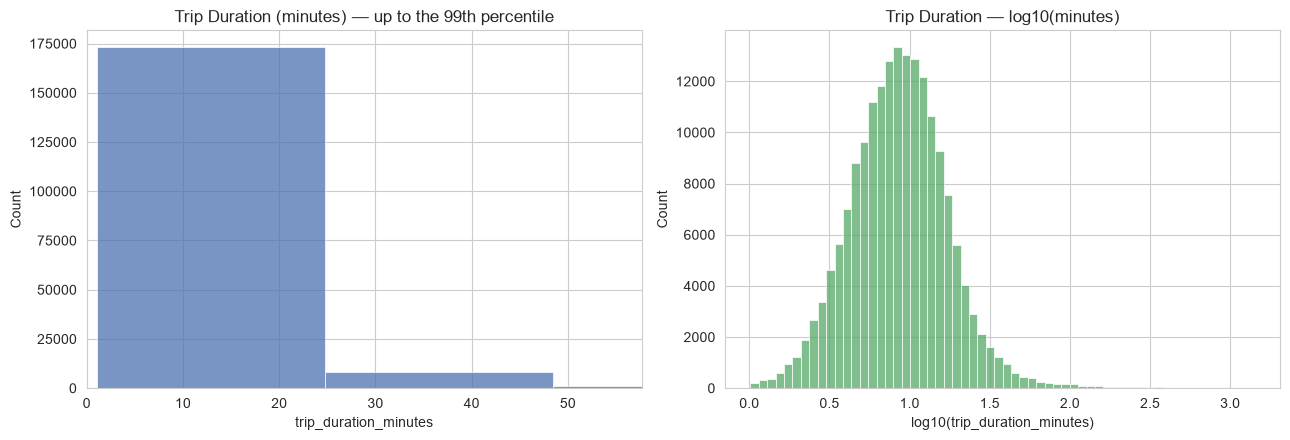

count    183412.000000
mean         12.101307
std          29.906496
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: trip_duration_minutes, dtype: float64


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['trip_duration_minutes'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_xlim(0, df['trip_duration_minutes'].quantile(0.99))
axes[0].set_title('Trip Duration (minutes) — up to the 99th percentile')
axes[0].set_xlabel('trip_duration_minutes')

sns.histplot(np.log10(df['trip_duration_minutes']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('Trip Duration — log10(minutes)')
axes[1].set_xlabel('log10(trip_duration_minutes)')

plt.tight_layout()
plt.show()

print(df['trip_duration_minutes'].describe())


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\1961118940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='user_type', order=order, palette=['#4C72B0', '#DD8452'])


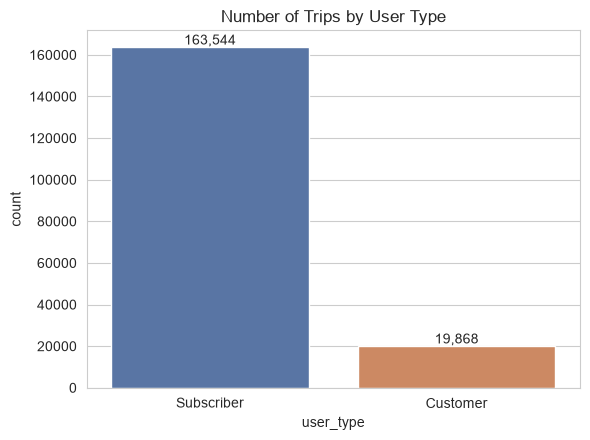

user_type
Subscriber    163544
Customer       19868
Name: count, dtype: int64
user_type
Subscriber    89.17
Customer      10.83
Name: proportion, dtype: float64


In [80]:
plt.figure(figsize=(6, 4.5))
order = df['user_type'].value_counts().index
ax = sns.countplot(data=df, x='user_type', order=order, palette=['#4C72B0', '#DD8452'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Number of Trips by User Type')
plt.tight_layout()
plt.show()

print(df['user_type'].value_counts())
print((df['user_type'].value_counts(normalize=True) * 100).round(2))

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\4002982782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#4C72B0', '#DD8452', '#55A868'])


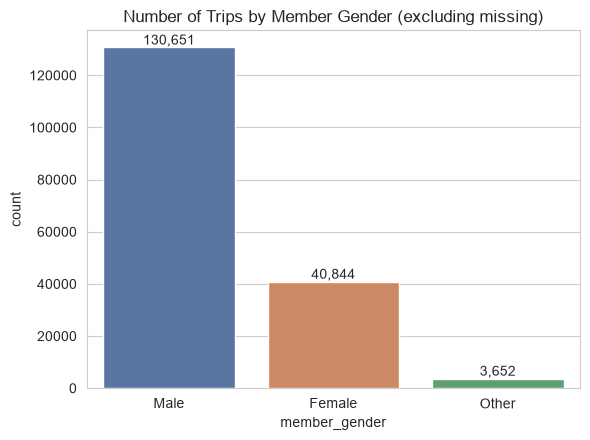

member_gender
Male      130651
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64
member_gender
Male      74.60
Female    23.32
Other      2.09
Name: proportion, dtype: float64


In [81]:
plt.figure(figsize=(6, 4.5))
gender_counts = df['member_gender'].value_counts()
ax = sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=['#4C72B0', '#DD8452', '#55A868'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Number of Trips by Member Gender (excluding missing)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

print(df['member_gender'].value_counts(dropna=False))
print((df['member_gender'].value_counts(normalize=True) * 100).round(2))

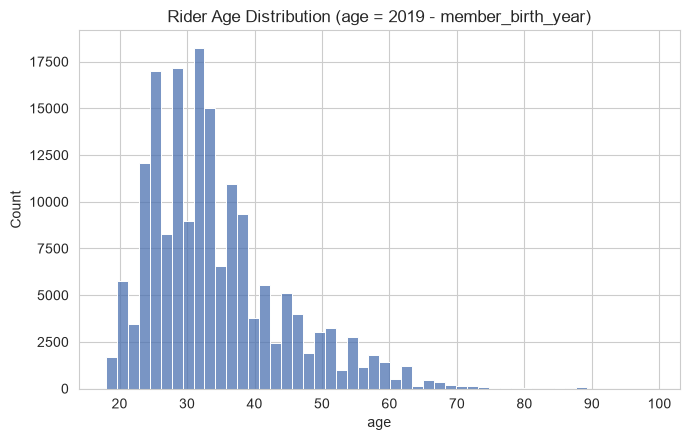

count    175075.000000
mean         34.158778
std           9.972079
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max          99.000000
Name: age, dtype: float64


In [82]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df['age'].dropna(), bins=50, color='#4C72B0')
plt.title('Rider Age Distribution (age = {ref_year} - member_birth_year)'.replace('{ref_year}', str(REFERENCE_YEAR)))
plt.xlabel('age')
plt.tight_layout()
plt.show()

print(df['age'].describe())


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\2857331370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=bs_counts.index, y=bs_counts.values, palette=['#4C72B0', '#DD8452'])


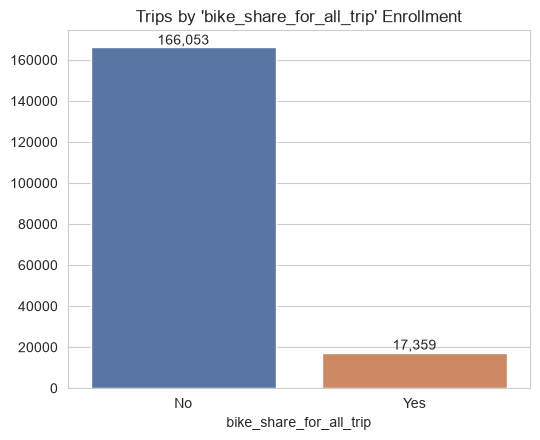

bike_share_for_all_trip
No     166053
Yes     17359
Name: count, dtype: int64
bike_share_for_all_trip
No     90.54
Yes     9.46
Name: proportion, dtype: float64


In [83]:
plt.figure(figsize=(5.5, 4.5))
bs_counts = df['bike_share_for_all_trip'].value_counts()
ax = sns.barplot(x=bs_counts.index, y=bs_counts.values, palette=['#4C72B0', '#DD8452'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Trips by 'bike_share_for_all_trip' Enrollment")
plt.tight_layout()
plt.show()

print(df['bike_share_for_all_trip'].value_counts())
print((df['bike_share_for_all_trip'].value_counts(normalize=True) * 100).round(2))

## 8. Bivariate Analysis

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\4283013332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='user_type', y='trip_duration_minutes', showfliers=False, palette=['#4C72B0', '#DD8452'])


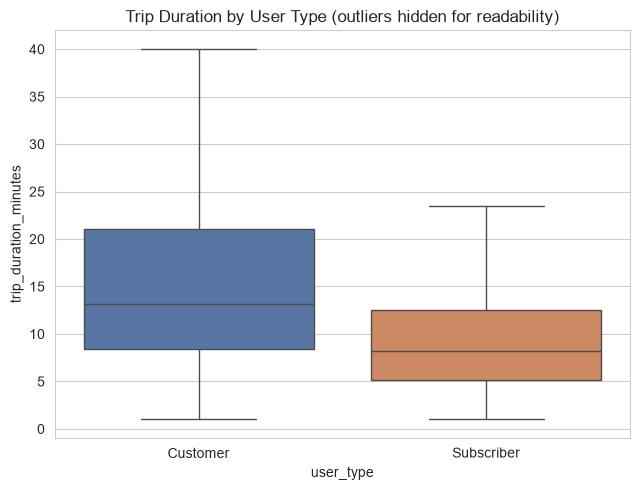

user_type
Customer      13.200000
Subscriber     8.166667
Name: trip_duration_minutes, dtype: float64

user_type
Customer      23.874417
Subscriber    10.671061
Name: trip_duration_minutes, dtype: float64


In [84]:
plt.figure(figsize=(6.5, 5))
sns.boxplot(data=df, x='user_type', y='trip_duration_minutes', showfliers=False, palette=['#4C72B0', '#DD8452'])
plt.title('Trip Duration by User Type (outliers hidden for readability)')
plt.ylabel('trip_duration_minutes')
plt.tight_layout()
plt.show()

print(df.groupby('user_type')['trip_duration_minutes'].median())
print()
print(df.groupby('user_type')['trip_duration_minutes'].mean())

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\1728929407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='member_gender', y='trip_duration_minutes', showfliers=False,


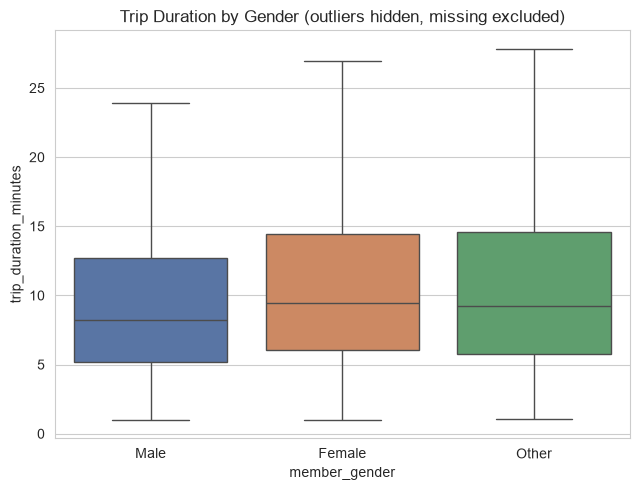

member_gender
Female    9.466667
Male      8.216667
Other     9.250000
Name: trip_duration_minutes, dtype: float64


In [85]:
plt.figure(figsize=(6.5, 5))
sns.boxplot(data=df, x='member_gender', y='trip_duration_minutes', showfliers=False,
            order=['Male', 'Female', 'Other'], palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Trip Duration by Gender (outliers hidden, missing excluded)')
plt.tight_layout()
plt.show()

print(df.groupby('member_gender')['trip_duration_minutes'].median())


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\1411933470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='trip_duration_minutes', showfliers=False,


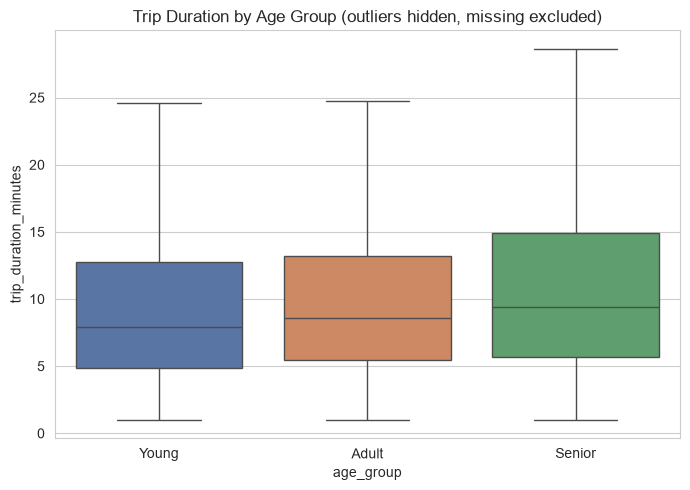

age_group
Adult     8.566667
Senior    9.408333
Young     7.933333
Name: trip_duration_minutes, dtype: float64

age_group
Adult     148001
Young      22992
NaN         8337
Senior      4082
Name: count, dtype: int64


In [86]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='age_group', y='trip_duration_minutes', showfliers=False,
            order=['Young', 'Adult', 'Senior'], palette=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Trip Duration by Age Group (outliers hidden, missing excluded)')
plt.tight_layout()
plt.show()

print(df.groupby('age_group', observed=True)['trip_duration_minutes'].median())
print()
print(df['age_group'].value_counts(dropna=False))


bike_share_for_all_trip      No    Yes
user_type                             
Customer                  19868      0
Subscriber               146185  17359

bike_share_for_all_trip      No    Yes
user_type                             
Customer                 100.00   0.00
Subscriber                89.39  10.61


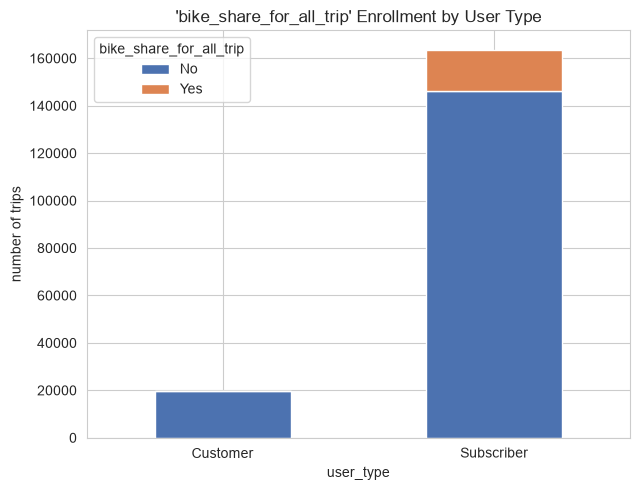

In [87]:
ct = pd.crosstab(df['user_type'], df['bike_share_for_all_trip'])
print(ct)
print()
ct_pct = pd.crosstab(df['user_type'], df['bike_share_for_all_trip'], normalize='index') * 100
print(ct_pct.round(2))

ct.plot(kind='bar', stacked=True, figsize=(6.5, 5), color=['#4C72B0', '#DD8452'])
plt.title("'bike_share_for_all_trip' Enrollment by User Type")
plt.ylabel('number of trips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_1032\3317862438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_stations.index, x=top_stations.values, palette='Blues_r')


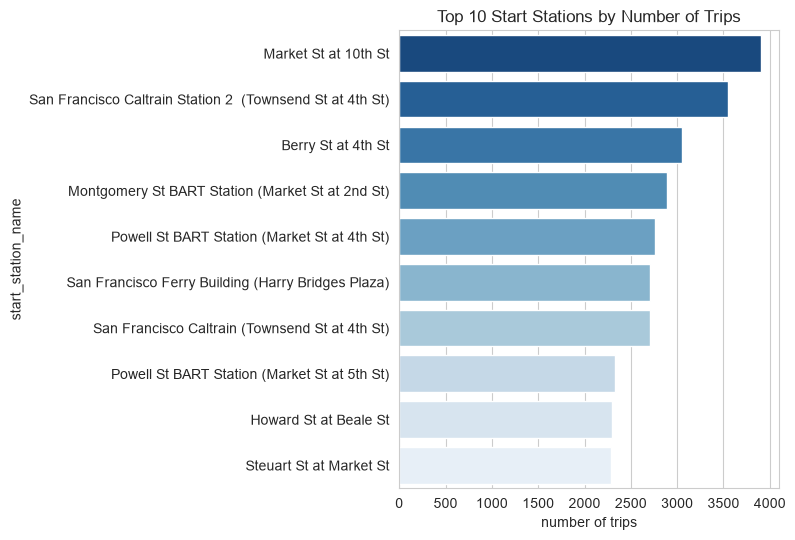

start_station_name
Market St at 10th St                                         3904
San Francisco Caltrain Station 2  (Townsend St at 4th St)    3544
Berry St at 4th St                                           3052
Montgomery St BART Station (Market St at 2nd St)             2895
Powell St BART Station (Market St at 4th St)                 2760
San Francisco Ferry Building (Harry Bridges Plaza)           2710
San Francisco Caltrain (Townsend St at 4th St)               2703
Powell St BART Station (Market St at 5th St)                 2327
Howard St at Beale St                                        2293
Steuart St at Market St                                      2283
Name: count, dtype: int64


In [88]:
top_stations = df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(8, 5.5))
sns.barplot(y=top_stations.index, x=top_stations.values, palette='Blues_r')
plt.title('Top 10 Start Stations by Number of Trips')
plt.xlabel('number of trips')
plt.tight_layout()
plt.show()

print(top_stations)

## 9. Multivariate Analysis

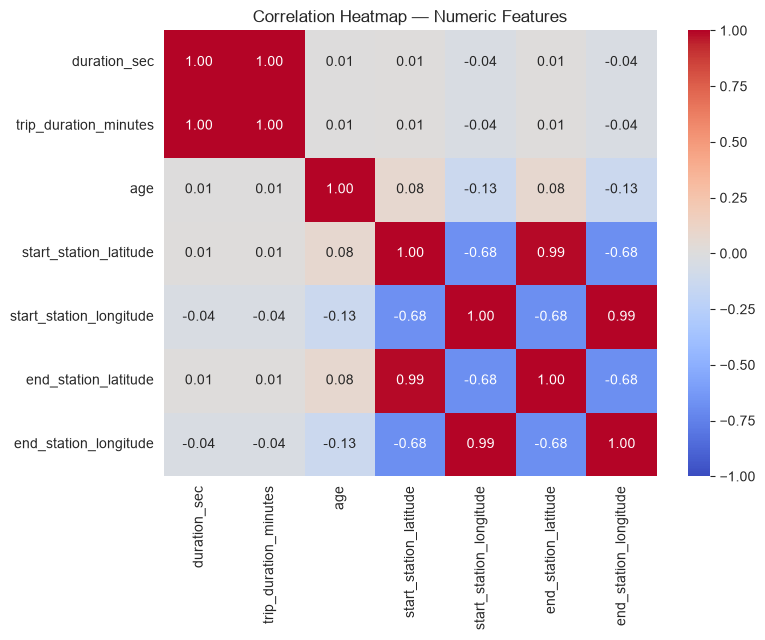

,duration_sec,trip_duration_minutes,age,start_station_latitude,start_station_longitude,end_station_latitude,end_station_longitude
duration_sec,1.000000,1.000000,0.006210,0.010513,-0.037930,0.010873,-0.038906
trip_duration_minutes,1.000000,1.000000,0.006210,0.010513,-0.037930,0.010873,-0.038906
age,0.006210,0.006210,1.000000,0.075833,-0.127377,0.075958,-0.128325
start_station_latitude,0.010513,0.010513,0.075833,1.000000,-0.677227,0.989969,-0.682637
start_station_longitude,-0.037930,-0.037930,-0.127377,-0.677227,1.000000,-0.681815,0.992410
end_station_latitude,0.010873,0.010873,0.075958,0.989969,-0.681815,1.000000,-0.684197
end_station_longitude,-0.038906,-0.038906,-0.128325,-0.682637,0.992410,-0.684197,1.000000


In [89]:
numeric_cols = ['duration_sec', 'trip_duration_minutes', 'age',
                'start_station_latitude', 'start_station_longitude',
                'end_station_latitude', 'end_station_longitude']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

corr

member_gender  Female   Male  Other
user_type                          
Customer        14.32  12.53  12.20
Subscriber       8.98   7.92   8.85


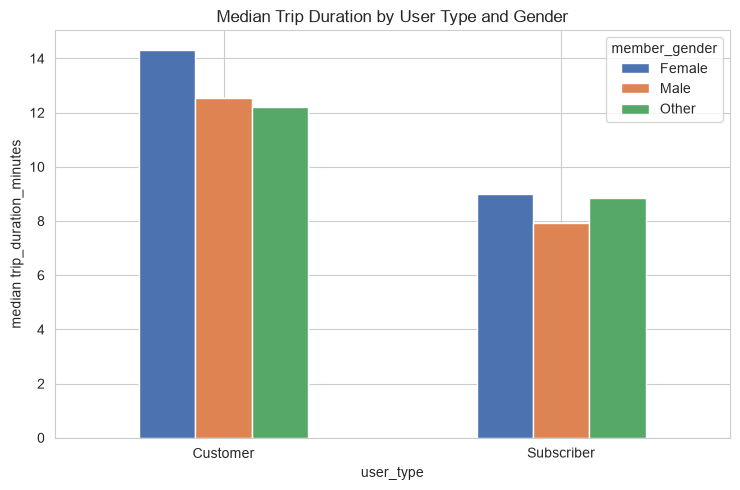

In [90]:
pivot = df.pivot_table(values='trip_duration_minutes', index='user_type', columns='member_gender',
                        aggfunc='median', observed=True)
print(pivot.round(2))

pivot.plot(kind='bar', figsize=(7.5, 5), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Median Trip Duration by User Type and Gender')
plt.ylabel('median trip_duration_minutes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

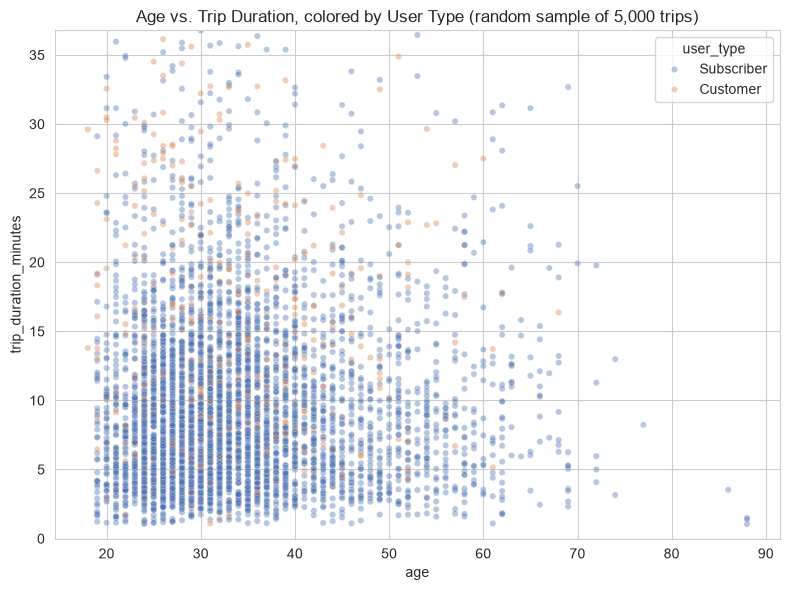

In [91]:
sample = df.dropna(subset=['age', 'trip_duration_minutes']).sample(
    n=min(5000, df.dropna(subset=['age', 'trip_duration_minutes']).shape[0]), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x='age', y='trip_duration_minutes', hue='user_type',
                alpha=0.4, s=20, palette=['#4C72B0', '#DD8452'])
plt.ylim(0, sample['trip_duration_minutes'].quantile(0.98))
plt.title('Age vs. Trip Duration, colored by User Type (random sample of 5,000 trips)')
plt.tight_layout()
plt.show()


## 11. Final Clean Dataset

In [92]:
print("=== SHAPE COMPARISON ===")
print("Original (df_raw):", df_raw.shape)
print("Cleaned  (df):     ", df.shape)
print("Rows removed:", df_raw.shape[0] - df.shape[0], "-> these were the confirmed exact duplicates from Section 4.1")
print("Columns added:", df.shape[1] - df_raw.shape[1], "->", [c for c in df.columns if c not in df_raw.columns])

=== SHAPE COMPARISON ===
Original (df_raw): (183416, 16)
Cleaned  (df):      (183412, 19)
Rows removed: 4 -> these were the confirmed exact duplicates from Section 4.1
Columns added: 3 -> ['trip_duration_minutes', 'age', 'age_group']


In [93]:
print("=== MISSING VALUES: BEFORE vs AFTER ===")
before = df_raw.isna().sum()
after = df.reindex(columns=df_raw.columns).isna().sum()  # compare on the original column set only
comparison = pd.DataFrame({'missing_before': before, 'missing_after': after})
comparison['difference'] = comparison['missing_after'] - comparison['missing_before']
comparison[comparison['missing_before'] > 0]


=== MISSING VALUES: BEFORE vs AFTER ===


,missing_before,missing_after,difference
start_station_id,197,197,0
start_station_name,197,197,0
end_station_id,197,197,0
end_station_name,197,197,0
member_birth_year,8265,8337,72
member_gender,8265,8265,0


In [94]:
print("Duplicate rows remaining:", df.duplicated().sum())
print()
df.info()


Duplicate rows remaining: 0

<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  str    
 13  member_birth_year        175075 non-null 

In [95]:
print("Engineered features present:")
for c in ['trip_duration_minutes', 'age', 'age_group']:
    print(f" - {c}: dtype={df[c].dtype}, missing={df[c].isna().sum()}")

print()
df.head()

Engineered features present:
 - trip_duration_minutes: dtype=float64, missing=0
 - age: dtype=float64, missing=8337
 - age_group: dtype=str, missing=8337



,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,trip_duration_minutes,age,age_group
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,869.750000,35.0,Adult
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No,708.683333,NaN,NaN
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,1030.900000,47.0,Adult
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,608.166667,30.0,Adult
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,26.416667,45.0,Adult


In [96]:
df.to_csv('fordgobike_201902_cleaned.csv', index=False)
print("Cleaned dataset exported to 'fordgobike_201902_cleaned.csv'")
print("Final shape:", df.shape)

Cleaned dataset exported to 'fordgobike_201902_cleaned.csv'
Final shape: (183412, 19)
